# **Neural Networks**

In [ ]:
from dataclasses import dataclass
import pickle
import gzip
import random
import numpy as np
from PIL import Image, ImageOps
from time import time

# **Activation Function**

## **Sigmoid Function**
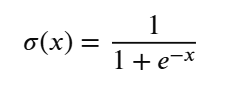

In [ ]:
def sigmoid(z):
  return 1.0/(1.0+np.exp(-z))

In [ ]:
def sigmoid_prime(z):
  return sigmoid(z)*(1-sigmoid(z))

In [ ]:
def cost_derivative(output_activations,y):
  return (output_activations-y)

In [ ]:
@dataclass
class Network:
  num_layers: int
  biases: list
  weights: list

def init_network(layers):
  return Network(
      len(layers),
      [np.random.randn(y,1) for y in layers[1:]],
      [np.random.randn(y,x) for x,y in zip(layers[:-1],layers[1:])]
  )

## **Forward Propagation Function**

In [ ]:
def feedforward(nn,a):
  for b,w in zip(nn.biases,nn.weights):
    a = sigmoid(np.dot(w,a)+b)
  return a

## **Evaluation Function**

In [ ]:
def evaluate(nn,test_data):
  test_results = [(np.argmax(feedforward(nn,x)),y) for (x,y) in test_data]
  return sum(int(x==y) for (x,y) in test_results)

## **Learning Function**

In [ ]:
def learn(nn, training_data, epochs, mini_batch_size, learning_rate, test_data = None):
    n = len(training_data)

    for j in range(epochs):
        random.shuffle(training_data) # that's where "stochastic" comes from

        mini_batches = [
            training_data[k: k + mini_batch_size] for k in range(0, n, mini_batch_size)
        ]

        for mini_batch in mini_batches:
            stochastic_gradient_descent(nn, mini_batch, learning_rate) # that's where learning really happes

        if test_data:
            print('Epoch {0}: accuracy {1}%'.format(f'{j + 1:2}', 100.0 * evaluate(nn, test_data) / len(test_data)))
        else:
            print('Epoch {0} complete.'.format(f'{j + 1:2}'))

In [ ]:
def stochastic_gradient_descent(nn, mini_batch, eta):
    # "nabla" is the gradient symbol
    nabla_b = [np.zeros(b.shape) for b in nn.biases]
    nabla_w = [np.zeros(w.shape) for w in nn.weights]

    X = np.hstack([x for x, y in mini_batch])

    Y = np.hstack([y for x, y in mini_batch])
    nabla_b, nabla_w = backprop(
      nn,
      X,
      Y
    )


 #   for x, y in mini_batch:
 #       delta_nabla_b, delta_nabla_w = backprop(nn, x, y) # compute the gradient

        # note that here we call the return values 'delta_nabla', while in the
        # backprop function we call them 'nabla'

  #      nabla_b = [nb + dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
  #      nabla_w = [nw + dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]


    nn.weights = [w - eta * nw
              for w, nw in zip(nn.weights, nabla_w)]

    nn.biases = [b - eta * nb
             for b, nb in zip(nn.biases, nabla_b)]

In [ ]:
def backprop(nn, X, Y):
    m = X.shape[1]
    nabla_b = [np.zeros(b.shape) for b in nn.biases]
    nabla_w = [np.zeros(w.shape) for w in nn.weights]

    # feedforward
    activation = X    # first layer activation is just its input
    activations = [X] # list to store all activations, layer by layer
    zs = []           # list to store all z vectors, layer by layer

    for b, w in zip(nn.biases, nn.weights):
        z = np.dot(w, activation) + b  # calculate z for the current layer
        zs.append(z)                   # store
        activation = sigmoid(z)        # layer output
        activations.append(activation) # store

    # backward pass

    # 1. starting from the output layer

    delta = (activations[-1] - Y) * sigmoid_prime(zs[-1])

    #delta = cost_derivative(activations[-1], Y) * sigmoid_prime(zs[-1])


    nabla_b[-1] = np.sum(
        delta,
        axis=1,
        keepdims=True
    ) / m
    m = X.shape[1]

    nabla_w[-1] = np.dot(
        delta,
        activations[-2].T
    ) / m

    # 2. continue back to the input layer (i is the layer index, we're using i instead of l
    #    to improve readability -- l looks too much like 1)
    for i in range(2, nn.num_layers): # starting from the next-to-last layer
        z = zs[-i]
        sp = sigmoid_prime(z)
        delta = np.dot(nn.weights[-i + 1].transpose(), delta) * sp

        nabla_b[-i] = np.sum(
          delta,
          axis=1,
          keepdims=True
        ) / m
        nabla_w[-i] = np.dot(
          delta,
          activations[-i-1].T
        ) / m

    return (nabla_b, nabla_w)

In [ ]:
def load_data():
    f = gzip.open('/content/mnist.pkl.gz', 'rb')
    training_data, validation_data, test_data = pickle.load(f, encoding="bytes")
    f.close()

    return (training_data, validation_data, test_data)

In [ ]:
def load_data_wrapper():
    tr_d, va_d, te_d = load_data()

    training_inputs = [np.reshape(x, (784, 1)) for x in tr_d[0]]
    training_results = [one_hot_encode(y) for y in tr_d[1]]
    training_data = zip(training_inputs, training_results)
    validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]]
    validation_data = zip(validation_inputs, va_d[1])
    test_inputs = [np.reshape(x, (784, 1)) for x in te_d[0]]
    test_data = zip(test_inputs, te_d[1])

    return (list(training_data), list(validation_data), list(test_data))

In [ ]:
def one_hot_encode(j):
  e=np.zeros((10,1))
  e[j]=1.0
  return e

In [ ]:
def print_shape(name,data):
  print('Shape of {0} : {1}'.format(name,data.shape))

In [ ]:
training_data, validation_data, test_data = load_data_wrapper() # load data

nn = init_network([784, 30, 10])

for l in range(0, nn.num_layers - 1):
    print('\nNetwork layer {0}'.format(l + 2)) # disregard the input layer
    print_shape('weights', nn.weights[l])
    print_shape('biases', nn.biases[l])

# hyper parameters
epochs = 15
mini_batch_size = 10
learning_rate = 3.0

print('\nLearning process started...\n')

time_start = time()

learn(nn, training_data, epochs, mini_batch_size, learning_rate, test_data)

time_end = time()

time_elapsed = time_end - time_start

print('\nLearning process complete in {0} seconds ({1} seconds per epoch)!\n'.format(f'{time_elapsed:.0f}', f'{time_elapsed / epochs:.1f}'))

print('Validation (with yet unseen data): accuracy {0}%'.format(100.0 * evaluate(nn, validation_data) / len(validation_data)))


Network layer 2
Shape of weights : (30, 784)
Shape of biases : (30, 1)

Network layer 3
Shape of weights : (10, 30)
Shape of biases : (10, 1)

Learning process started...

Epoch  1: accuracy 82.05%
Epoch  2: accuracy 83.05%
Epoch  3: accuracy 84.26%
Epoch  4: accuracy 84.76%
Epoch  5: accuracy 84.63%
Epoch  6: accuracy 85.08%
Epoch  7: accuracy 93.57%
Epoch  8: accuracy 94.24%
Epoch  9: accuracy 93.91%
Epoch 10: accuracy 94.3%
Epoch 11: accuracy 94.61%
Epoch 12: accuracy 94.06%
Epoch 13: accuracy 94.48%
Epoch 14: accuracy 94.63%
Epoch 15: accuracy 94.56%

Learning process complete in 32 seconds (2.1 seconds per epoch)!

Validation (with yet unseen data): accuracy 95.1%


In [ ]:
def load_image(file_name):
    digit = Image.open(file_name)

    # invert, so that background is black (zeros)
    digit = ImageOps.invert(digit)

    pixels = digit.load()

    return np.array(digit).reshape((784, 1)) / 255

In [ ]:
def recognize_image(path, file):
    x = load_image(path.format(file))

    y = feedforward(nn, x)

    bitmap = x.reshape((28, 28))

    file_num = int(file)
    result = y.argmax()

    if file_num == result:
        ev = 'correctly'
    else:
        ev = 'incorrectly'

    print(file, 'was', ev, 'recognized as', result)

In [ ]:
print('Non-MNIST digits:\n')

for file in range(0,10):
    recognize_image('/content/{0}.png', file)

Non-MNIST digits:

0 was correctly recognized as 0
1 was correctly recognized as 1
2 was incorrectly recognized as 3
3 was correctly recognized as 3
4 was correctly recognized as 4
5 was correctly recognized as 5
6 was correctly recognized as 6
7 was incorrectly recognized as 3
8 was correctly recognized as 8
9 was correctly recognized as 9
